# GPS Session Physical Report

**Author:** Isabella Sale · Performance & Physiological Data Analyst

Parsing a real **10 Hz Catapult GPS export** (36,000 samples from a 60-minute rugby training session) into the one-page physical summary a sports scientist hands to coaches after every session — total distance, work rate, speed-zone distribution, Player Load and heart-rate response.


## 1 · Load the raw feed

The Catapult export has a one-line title above the header row, so we skip it and standardise the column names.


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("catapult_rugby_training_session.csv", skiprows=1)
df.columns = [c.strip() for c in df.columns]
print(df.shape, "samples")
df[["Seconds","Velocity (km/h)","Odometer (m)","Player Load (au)","Heart Rate (bpm)","Session Phase"]].head()


(36000, 11) samples


## 2 · Movement trace

The starting point is the athlete's movement itself — latitude/longitude coloured by running speed.


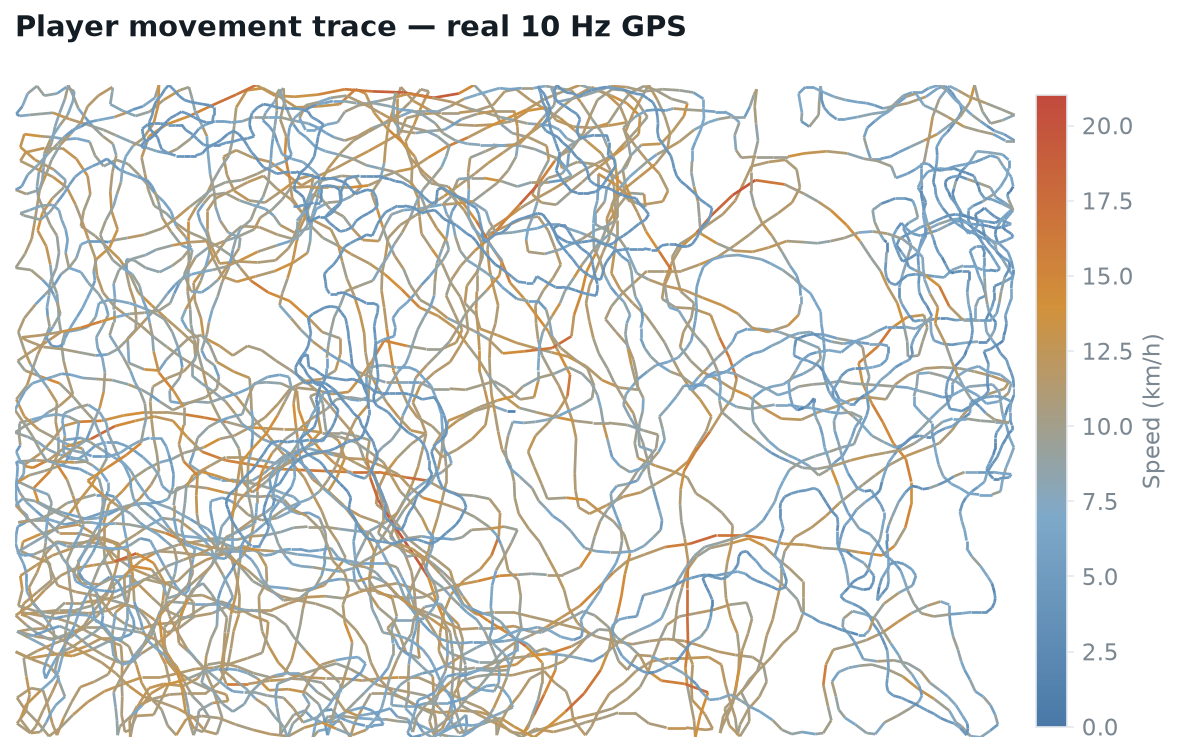

In [ ]:
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

lat, lon = df["Latitude"].values, df["Longitude"].values
mx = np.cos(np.radians(lat.mean())) * lon; my = lat
pts = np.array([mx, my]).T.reshape(-1,1,2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
cmap = LinearSegmentedColormap.from_list("i", ["#4A79A8","#7FA9C9","#D2913A","#C24A3D"])
lc = LineCollection(segs, cmap=cmap, array=df["Velocity (km/h)"].values[:-1], linewidths=1.2)
fig, ax = plt.subplots(figsize=(8,5)); ax.add_collection(lc)
ax.autoscale(); ax.set_aspect("equal"); ax.axis("off")
fig.colorbar(lc, label="Speed (km/h)"); plt.show()


## 3 · Physical summary

Distance comes straight from the odometer; **speed-zone distance is the time-integral of velocity within each band** (Σ v·Δt) — not a naive sample-count.


In [ ]:
dt = 0.1  # 10 Hz
ZONES = [("Z1 <6",0,6),("Z2 6-12",6,12),("Z3 12-15",12,15),("Z4 15-20",15,20),("Z5 >20",20,99)]
v_kmh, v_ms = df["Velocity (km/h)"], df["Velocity (m/s)"]
step = v_ms * dt
zones = {name: float(step[(v_kmh>=lo)&(v_kmh<hi)].sum()) for name,lo,hi in ZONES}

summary = {
    "total_distance_m":    round(df["Odometer (m)"].iloc[-1]),
    "work_rate_m_per_min": round(df["Odometer (m)"].iloc[-1] / (df["Seconds"].iloc[-1]/60)),
    "peak_speed_kmh":      round(v_kmh.max(),1),
    "player_load_au":      round(df["Player Load (au)"].iloc[-1]),
    "avg_hr_bpm":          round(df["Heart Rate (bpm)"].mean()),
}
for k,val in summary.items(): print(f"{k:22} {val}")
print("\nzone distance (m):"); [print(f"  {k:10} {round(v):>6}") for k,v in zones.items()]


total_distance_m       8382
work_rate_m_per_min    140
peak_speed_kmh         21.0
player_load_au         796
avg_hr_bpm             138

zone distance (m):
  Z1 <6        1173
  Z2 6-12      5879
  Z3 12-15     1134
  Z4 15-20      193
  Z5 >20          3


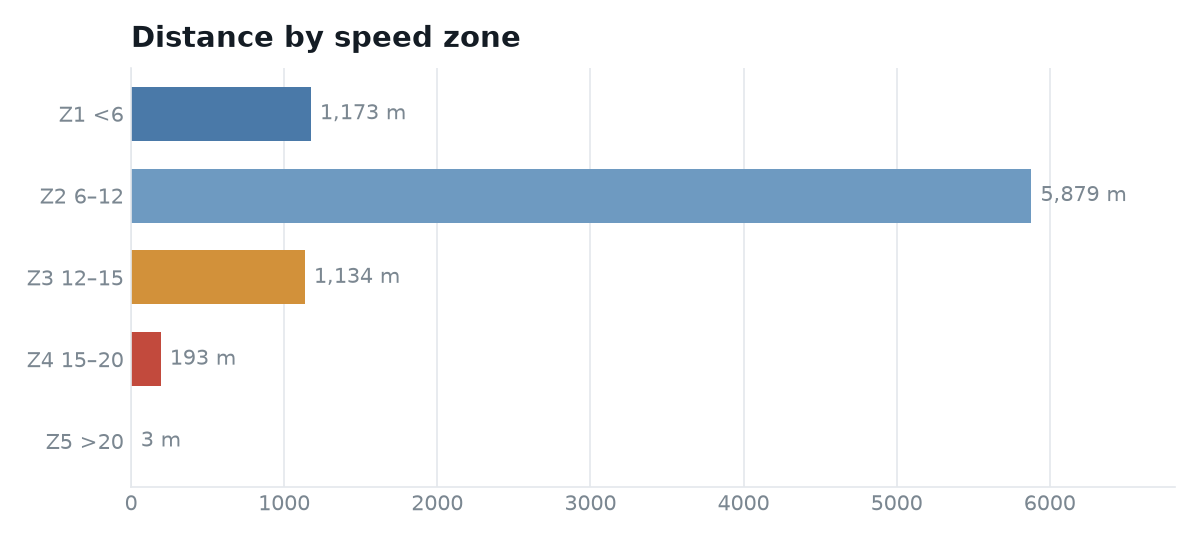

In [ ]:
fig, ax = plt.subplots(figsize=(8,3.5))
ax.barh(list(zones)[::-1], list(zones.values())[::-1],
        color=["#8E2E24","#C24A3D","#D2913A","#6E9AC1","#4A79A8"])
ax.set_title("Distance by speed zone", loc="left", weight="bold"); plt.show()


## 4 · Per-phase demand

Splitting the session on Catapult's phase flag shows exactly where the physical demand sits.


In [ ]:
g = df.groupby("Session Phase", sort=False)
phase = pd.DataFrame({
    "distance_m":     (g["Odometer (m)"].last() - g["Odometer (m)"].first()).round(),
    "peak_speed_kmh":  g["Velocity (km/h)"].max().round(1),
    "avg_hr_bpm":      g["Heart Rate (bpm)"].mean().round(),
})
phase


                  distance_m  peak_speed_kmh  avg_hr_bpm
Session Phase                                          
Warm-up               1868.0            14.3       144.0
Movement prep         1190.0            21.0       148.0
Skills - passing       994.0            13.7       128.0
Unit drills           1335.0            16.8       135.0
Conditioning           724.0            15.9       137.0
Small-sided game      1768.0            17.4       152.0
Cool-down              502.0             6.4       115.0


## Takeaway

An aerobic session — 70% of distance in the jogging band — but with real high-velocity exposure concentrated in **movement prep** (peak 21.0 km/h) and the **small-sided game**. Delivered consistently, this report lets staff compare each athlete against their own norm and feed accurate load into the weekly plan.

*Reproducible end-to-end: `python session_report.py` regenerates every number and chart.*
